In [2]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index
from utils import e_r_cpa_numerator, e_r_cpa, hl2, hl2prime

In [3]:
x = linspace(0, 10)
jv1 = jv(0, x)
yv1 = yv(0, x)
hv2 = hankel2(0, x)

# Verifying scipy hankel functions

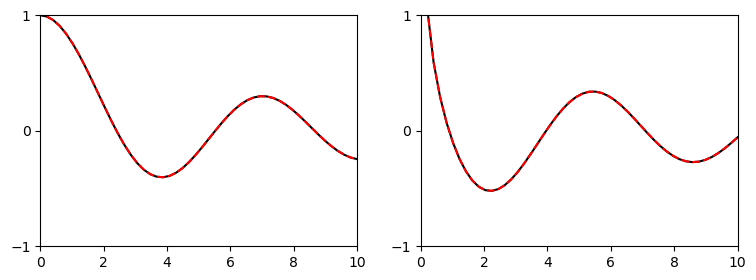

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(x, jv1, color="black")
ax1.plot(x, hv2.real, color="red", linestyle="dashed")
ax1.set_ylim(-1, 1);
ax1.set_xlim(0, 10);
ax1.set_yticks([-1, 0, 1])

ax2.plot(x, -yv1, color="black")
ax2.plot(x, hv2.imag, color="red", linestyle="dashed")
ax2.set_ylim(-1, 1);
ax2.set_xlim(0, 10);
ax2.set_yticks([-1, 0, 1]);

## Verifying analytic derivatives 

In [8]:
x_s = linspace(0.1, 10, 100, endpoint=True)

In [9]:
analytic_derivatives_1 = zeros(100, dtype=complex)
numerical_derivatives_1 = zeros(100, dtype=complex)

analytic_derivatives_2 = zeros(100, dtype=complex)
numerical_derivatives_2 = zeros(100, dtype=complex)

deltax = 0.01
for (i, x) in enumerate(x_s):
    l = 1
    analytic_derivatives_1[i] = hl2prime(1, x)
    numerical_derivatives_1[i] = (hl2(l, x+deltax/2)-hl2(l, x-deltax/2))/deltax

    l = 2
    analytic_derivatives_2[i] = hl2prime(l, x)
    numerical_derivatives_2[i] = (hl2(l, x+deltax/2)-hl2(l, x-deltax/2))/deltax

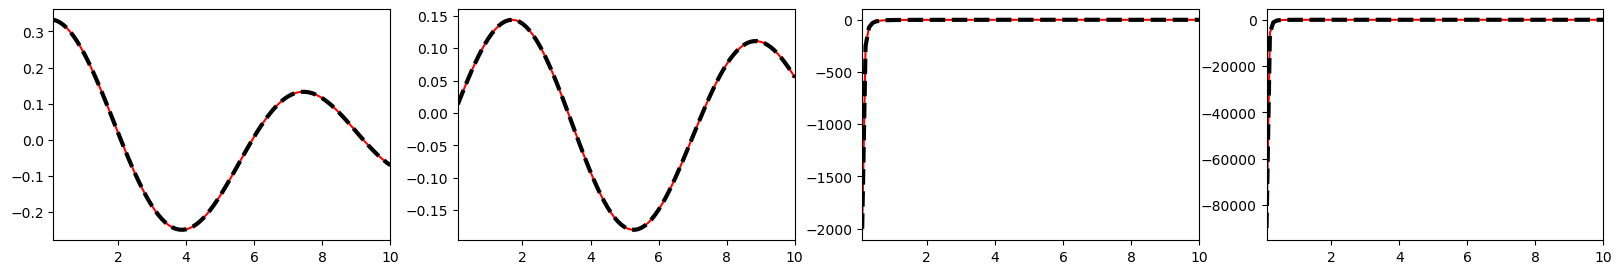

In [10]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 3))
x = linspace(0.1, 10, 100, endpoint=True)
ax1.plot(x, numerical_derivatives_1.real, color="red")
ax1.plot(x, analytic_derivatives_1.real, linestyle="dashed", linewidth=3, color="black")
ax1.set_xlim(0.1, 10)

ax3.plot(x, numerical_derivatives_1.imag, color="red")
ax3.plot(x, analytic_derivatives_1.imag, linestyle="dashed", linewidth=3, color="black")
ax3.set_xlim(0.1, 10)

ax2.plot(x, numerical_derivatives_2.real, color="red")
ax2.plot(x, analytic_derivatives_2.real, linestyle="dashed", linewidth=3, color="black");
ax2.set_xlim(0.1, 10)

ax4.plot(x, numerical_derivatives_2.imag, color="red")
ax4.plot(x, analytic_derivatives_2.imag, linestyle="dashed", linewidth=3, color="black");
ax4.set_xlim(0.1, 10);

In [22]:
M = 1000
x = linspace(0.01, 1, M) # Free space kR

N = 1000
min_vals = zeros(N)
imepsv = linspace(2, 3, N)
l = 1 # order of mode (bessel/hankel function)

for (i, imeps) in enumerate(imepsv):
    epsilon = -2.6 + imeps*1j
    tm_numerator = e_r_cpa_numerator(l, x, epsilon)
    min_vals[i] = (abs(tm_numerator)).min()

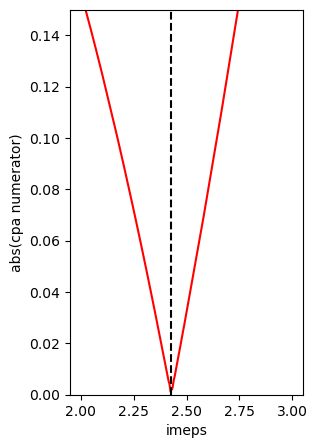

In [23]:
plt.figure(figsize=(3, 5))
plt.plot(imepsv, min_vals, color="red")
plt.ylim(0, 0.15)
plt.vlines(imepsv[argmin(min_vals)], 0, 0.2, linestyle="dashed", color="black")
plt.ylabel("abs(cpa numerator)")
plt.xlabel("imeps");

In [13]:
print(f"Imeps corresponding to CPA for fixed real value of dielectric at -2.6: {imepsv[argmin(min_vals)]}")

Imeps corresponding to CPA for fixed real value of dielectric at -2.6: 2.4254254254254253


# Find the radius corresponding to the above

In [14]:
M = 1000
x = linspace(0.01, 1, M) # Free space kR
epsilon = -2.6 + imepsv[argmin(min_vals)]*1j
l = 1 # order of mode (bessel/hankel function)
tm_cpa_numerator = e_r_cpa_numerator(l, x, epsilon)

In [15]:
print(f"kR corresponding to CPA: {x[argmin(abs(tm_cpa_numerator))]}")

kR corresponding to CPA: 0.8870270270270271


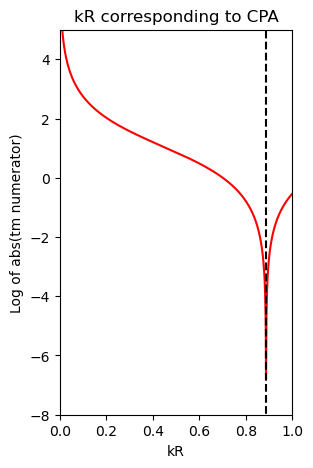

In [16]:
plt.figure(figsize=(3, 5))
plt.plot(x, log(abs(tm_cpa_numerator)), color="red")
plt.vlines([x[argmin(abs(tm_cpa_numerator))]], -10, 10, color="black", linestyle="dashed")
plt.xlim(0, 1)
plt.xlabel("kR")
plt.ylim(-8, 5)
plt.ylabel("Log of abs(tm numerator)");
plt.title("kR corresponding to CPA");

# Recreating figure 2(a)

In [17]:
M = N = 150
real_eps_v = linspace(-3, -1.5, N, endpoint=True)
im_eps_v = linspace(0.01, 3, M, endpoint=True)

In [18]:
epsilon_arr = real_eps_v.reshape((N, 1)).repeat(M,1) + 1j * im_eps_v.reshape((1, M)).repeat(N, 0); # A 150x150 array of epsilon values, where the row indexes the real part and the column indexes
# the imaginary part
xs = linspace(0.01, 1, 1000, endpoint=True)
sqrt_epsilon_arr = sqrt(epsilon_arr)
l = 1 # order of mode (bessel/hankel function)

In [19]:
best_real_epses = zeros(len(xs))
best_imag_epses = zeros(len(xs))

for (i, kr) in enumerate(xs):
    x = kr * ones((N, M))
    tm_numerator = e_r_cpa_numerator(l, kr, epsilon_arr)
    idx = argmin(abs(tm_numerator))
    row, col = unravel_index(idx, epsilon_arr.shape)
    best_real_epses[i] = real_eps_v[row]
    best_imag_epses[i] = im_eps_v[col]

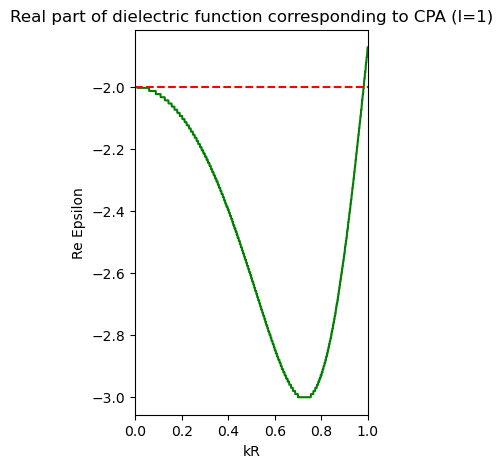

In [20]:
plt.figure(figsize=(3, 5))
plt.plot(xs, best_real_epses, color="green")
plt.xlabel("kR")
plt.ylabel("Re Epsilon")
plt.xlim(0, 1);
plt.hlines([-2], 0, 1, linestyle="dashed", label="Quasistatic epsilon", color="red")
plt.title("Real part of dielectric function corresponding to CPA (l=1)");

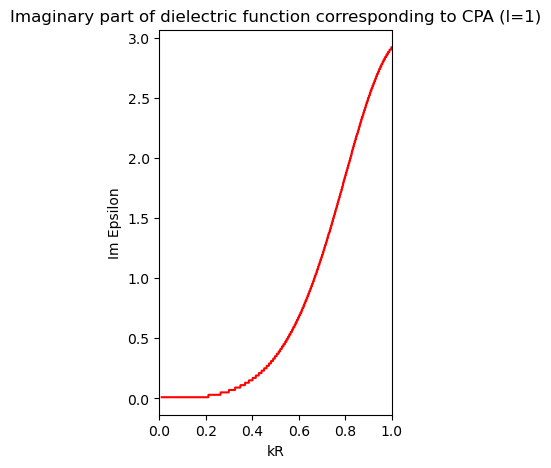

In [21]:
plt.figure(figsize=(3, 5))
plt.plot(xs, best_imag_epses, color="red")
plt.xlabel("kR")
plt.ylabel("Im Epsilon")
plt.xlim(0, 1);
plt.title("Imaginary part of dielectric function corresponding to CPA (l=1)");